In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
!pip install -q catboost
from catboost import CatBoostClassifier

SEED     = 42
DATA_DIR = '/content/drive/MyDrive/STEG_Fraud/'

df_client       = pd.read_csv(DATA_DIR + 'client_train.csv',  parse_dates=['creation_date'], dayfirst=True)
df_invoice      = pd.read_csv(DATA_DIR + 'invoice_train.csv', parse_dates=['invoice_date'],  dayfirst=True, low_memory=False)
df_client_test  = pd.read_csv(DATA_DIR + 'client_test.csv',   parse_dates=['creation_date'], dayfirst=True)
df_invoice_test = pd.read_csv(DATA_DIR + 'invoice_test.csv',  parse_dates=['invoice_date'],  dayfirst=True, low_memory=False)

def clean(df_c, df_i, prefix):
    df_c = df_c.copy(); df_i = df_i.copy()
    df_c.rename(columns={'disrict': 'district'}, inplace=True)
    df_c['client_id'] = df_c['client_id'].astype(str).str.replace(prefix, '').astype(int)
    df_i['client_id'] = df_i['client_id'].astype(str).str.replace(prefix, '').astype(int)
    df_i.drop_duplicates(inplace=True)
    for col, bad in [('counter_statue',      ['46','A','618','769','269375','420']),
                     ('reading_remarque',    ['5','207','413','203']),
                     ('counter_coefficient', ['5','11','8','33','50','9','20','10','4'])]:
        df_i[col] = df_i[col].astype(str).replace(bad, '99')
    return df_c, df_i

df_client,      df_invoice      = clean(df_client,      df_invoice,      'train_Client_')
df_client_test, df_invoice_test = clean(df_client_test, df_invoice_test, 'test_Client_')

print(f'Train clients: {len(df_client):,} | Invoice rows: {len(df_invoice):,}')
print('✅ Data loaded')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
Train clients: 135,493 | Invoice rows: 4,476,738
✅ Data loaded


In [4]:
def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}' for l,s in agg.columns]
    for lvl in [1,2,3,4]:
        agg[f'{prefix}cl{lvl}_cv'] = agg[f'{prefix}cl{lvl}_std'] / (agg[f'{prefix}cl{lvl}_mean'] + 1e-6)
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

def years_active(df, prefix):
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.dt.year.nunique()).rename(f'{prefix}years_active').reset_index()

def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()).rename(f'{prefix}avg_gap_days').reset_index()

def monthly_stats(df, prefix):
    df = df.copy()
    df['month'] = df['invoice_date'].dt.month
    df['total'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                   df['consommation_level_3'] + df['consommation_level_4'])
    monthly = df.groupby(['client_id','month'])['total'].mean().unstack(fill_value=0)
    monthly.columns = [f'{prefix}m{c}_mean' for c in monthly.columns]
    mean_cols = monthly.columns.tolist()
    monthly[f'{prefix}monthly_range'] = monthly[mean_cols].max(axis=1) - monthly[mean_cols].min(axis=1)
    monthly[f'{prefix}monthly_cv']    = monthly[mean_cols].std(axis=1) / (monthly[mean_cols].mean(axis=1) + 1e-6)
    return monthly.reset_index()

def yearly_trend(df, prefix):
    # Slope of consumption over years — dropping = suspicious
    df = df.copy()
    df['year']  = df['invoice_date'].dt.year
    df['total'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                   df['consommation_level_3'] + df['consommation_level_4'])
    yearly = df.groupby(['client_id','year'])['total'].mean().reset_index()

    def slope(x):
        if len(x) < 2: return 0
        years = x['year'].values
        vals  = x['total'].values
        return np.polyfit(years - years.mean(), vals, 1)[0]

    trend = yearly.groupby('client_id').apply(slope).rename(f'{prefix}yearly_slope')

    # Last year vs first year ratio
    first = yearly.groupby('client_id').first()['total'].rename(f'{prefix}first_yr_consum')
    last  = yearly.groupby('client_id').last()['total'].rename(f'{prefix}last_yr_consum')
    ratio = (last / (first + 1e-6)).rename(f'{prefix}yr_ratio')

    return pd.concat([trend, first, last, ratio], axis=1).reset_index()

def zero_ratio(df, prefix):
    df = df.copy()
    df['total'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                   df['consommation_level_3'] + df['consommation_level_4'])
    z = df.groupby('client_id')['total'].apply(lambda x: (x==0).mean()).rename(f'{prefix}zero_ratio')
    n = df.groupby('client_id')['total'].apply(lambda x: (x==0).sum()).rename(f'{prefix}zero_count')
    return pd.concat([z, n], axis=1).reset_index()

def build_features(df_c, df_i, region_rate=None, district_rate=None, catg_rate=None):
    df_c    = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()

    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])

    total_kwh_df = (df_i.groupby('client_id')[
        ['consommation_level_1','consommation_level_2',
         'consommation_level_3','consommation_level_4']]
        .sum().sum(axis=1).rename('total_kwh').reset_index())

    elec_dur = account_duration(df_elec, 'elec_')
    gaz_dur  = account_duration(df_gaz,  'gaz_')
    dur_feat = elec_dur.merge(gaz_dur, on='client_id', how='outer')
    dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()

    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        dur_feat,
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        total_kwh_df,
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
        monthly_stats(df_elec, 'elec_'),
        monthly_stats(df_gaz,  'gaz_'),
        yearly_trend(df_elec,  'elec_'),
        yearly_trend(df_gaz,   'gaz_'),
        zero_ratio(df_elec, 'elec_'),
        zero_ratio(df_gaz,  'gaz_'),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')

    if region_rate is not None:
        df_merged['region_fraud_rate']   = df_merged['region'].map(region_rate)
        df_merged['district_fraud_rate'] = df_merged['district'].map(district_rate)
        df_merged['catg_fraud_rate']     = df_merged['client_catg'].map(catg_rate)

    return df_merged

region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

print('Building train features...')
df_train_full = build_features(df_client, df_invoice,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)
print('Building test features...')
df_test_full  = build_features(df_client_test, df_invoice_test,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)

X = df_train_full.drop(columns=['client_id','target'])
y = df_train_full['target'].astype(int)
test_ids = df_test_full['client_id'].copy()
X_test   = df_test_full.drop(columns=['client_id','target'], errors='ignore')
X_test   = X_test.reindex(columns=X.columns, fill_value=np.nan)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()
X[cat_cols]      = X[cat_cols].fillna('missing')
X_test[cat_cols] = X_test[cat_cols].fillna('missing')

neg, pos = np.bincount(y)
print(f'Features: {X.shape[1]} | Class ratio: {neg/pos:.1f}')

# ── Target encoding inside CV folds to avoid leakage ─────────────────────────
te_cols = ['region', 'district', 'client_catg']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))
test_xgb, test_lgb, test_cat = [], [], []

global_mean = y.mean()

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_vl = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_vl = y.iloc[tr_idx],        y.iloc[val_idx]
    X_te       = X_test.copy()

    # Target encode on training fold only — apply to val and test
    for col in te_cols:
        te_map = y_tr.groupby(X_tr[col]).mean()
        X_tr[f'{col}_te'] = X_tr[col].map(te_map).fillna(global_mean)
        X_vl[f'{col}_te'] = X_vl[col].map(te_map).fillna(global_mean)
        X_te[f'{col}_te'] = X_te[col].map(te_map).fillna(global_mean)

    fold_cat_cols = cat_cols
    fold_num_cols = [c for c in X_tr.columns if c not in fold_cat_cols]

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), fold_num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), fold_cat_cols)
    ])
    X_tr_p   = pre.fit_transform(X_tr)
    X_vl_p   = pre.transform(X_vl)
    X_test_p = pre.transform(X_te)

    xgb_clf = XGBClassifier(
        n_estimators=1000, learning_rate=0.02, max_depth=5,
        subsample=0.75, colsample_bytree=0.75, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=neg/pos,
        eval_metric='auc', random_state=SEED, n_jobs=-1, tree_method='hist'
    )
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]
    test_xgb.append(xgb_clf.predict_proba(X_test_p)[:, 1])

    lgb_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.02, num_leaves=31,
        subsample=0.75, colsample_bytree=0.75, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]
    test_lgb.append(lgb_clf.predict_proba(X_test_p)[:, 1])

    cat_clf = CatBoostClassifier(
        iterations=1000, learning_rate=0.02, depth=5,
        l2_leaf_reg=3, subsample=0.75,
        scale_pos_weight=neg/pos,
        cat_features=fold_cat_cols,
        eval_metric='AUC', random_seed=SEED, verbose=0
    )
    cat_clf.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    oof_cat[val_idx] = cat_clf.predict_proba(X_vl)[:, 1]
    test_cat.append(cat_clf.predict_proba(X_te)[:, 1])

    print(f'Fold {fold} — XGB: {roc_auc_score(y_vl, oof_xgb[val_idx]):.4f} | '
          f'LGB: {roc_auc_score(y_vl, oof_lgb[val_idx]):.4f} | '
          f'CAT: {roc_auc_score(y_vl, oof_cat[val_idx]):.4f}')

print(f'\nOOF XGBoost : {roc_auc_score(y, oof_xgb):.4f}')
print(f'OOF LightGBM: {roc_auc_score(y, oof_lgb):.4f}')
print(f'OOF CatBoost: {roc_auc_score(y, oof_cat):.4f}')
print(f'OOF Blend   : {roc_auc_score(y, (oof_xgb+oof_lgb+oof_cat)/3):.4f}')

test_blend = (np.mean(test_xgb, axis=0) +
              np.mean(test_lgb, axis=0) +
              np.mean(test_cat, axis=0)) / 3

submission = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids.astype(str),
    'target':    test_blend
})
submission.to_csv(DATA_DIR + 'submission_v8.csv', index=False)
print(f'\n✅ Saved: submission_v8.csv')

Building train features...
Building test features...
Features: 144 | Class ratio: 16.9
Fold 1 — XGB: 0.8703 | LGB: 0.8713 | CAT: 0.8704
Fold 2 — XGB: 0.8745 | LGB: 0.8733 | CAT: 0.8722
Fold 3 — XGB: 0.8831 | LGB: 0.8845 | CAT: 0.8811
Fold 4 — XGB: 0.8677 | LGB: 0.8679 | CAT: 0.8677
Fold 5 — XGB: 0.8715 | LGB: 0.8718 | CAT: 0.8713

OOF XGBoost : 0.8734
OOF LightGBM: 0.8737
OOF CatBoost: 0.8725
OOF Blend   : 0.8757

✅ Saved: submission_v8.csv


In [ ]:
def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}' for l,s in agg.columns]
    for lvl in [1,2,3,4]:
        agg[f'{prefix}cl{lvl}_cv'] = agg[f'{prefix}cl{lvl}_std'] / (agg[f'{prefix}cl{lvl}_mean'] + 1e-6)
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

def years_active(df, prefix):
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.dt.year.nunique()).rename(f'{prefix}years_active').reset_index()

def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()).rename(f'{prefix}avg_gap_days').reset_index()

def monthly_stats(df, prefix):
    # Average consumption per month across all years — 12 features per level
    df = df.copy()
    df['month'] = df['invoice_date'].dt.month
    df['total_consum'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                          df['consommation_level_3'] + df['consommation_level_4'])
    # Monthly mean total consumption
    monthly = df.groupby(['client_id','month'])['total_consum'].mean().unstack(fill_value=0)
    monthly.columns = [f'{prefix}month_{c}_mean' for c in monthly.columns]
    # Monthly std — high variance across months = suspicious
    monthly_std = df.groupby(['client_id','month'])['total_consum'].std().unstack(fill_value=0)
    monthly_std.columns = [f'{prefix}month_{c}_std' for c in monthly_std.columns]
    result = monthly.join(monthly_std, how='left').reset_index()
    # Summary: max month, min month, range across months
    mean_cols = [c for c in result.columns if 'mean' in c]
    result[f'{prefix}monthly_range'] = result[mean_cols].max(axis=1) - result[mean_cols].min(axis=1)
    result[f'{prefix}monthly_cv']    = result[mean_cols].std(axis=1) / (result[mean_cols].mean(axis=1) + 1e-6)
    return result

def zero_ratio(df, prefix):
    df = df.copy()
    df['total'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                   df['consommation_level_3'] + df['consommation_level_4'])
    z = df.groupby('client_id')['total'].apply(lambda x: (x==0).mean()).rename(f'{prefix}zero_ratio')
    return z.reset_index()

def build_features(df_c, df_i, region_rate=None, district_rate=None, catg_rate=None):
    df_c    = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()

    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])

    total_kwh_df = (df_i.groupby('client_id')[
        ['consommation_level_1','consommation_level_2',
         'consommation_level_3','consommation_level_4']]
        .sum().sum(axis=1).rename('total_kwh').reset_index())

    elec_dur = account_duration(df_elec, 'elec_')
    gaz_dur  = account_duration(df_gaz,  'gaz_')
    dur_feat = elec_dur.merge(gaz_dur, on='client_id', how='outer')
    dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()

    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        dur_feat,
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        total_kwh_df,
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
        monthly_stats(df_elec, 'elec_'),
        monthly_stats(df_gaz,  'gaz_'),
        zero_ratio(df_elec, 'elec_'),
        zero_ratio(df_gaz,  'gaz_'),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')

    if region_rate is not None:
        df_merged['region_fraud_rate']   = df_merged['region'].map(region_rate)
        df_merged['district_fraud_rate'] = df_merged['district'].map(district_rate)
        df_merged['catg_fraud_rate']     = df_merged['client_catg'].map(catg_rate)

    return df_merged

region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

print('Building train features...')
df_train_full = build_features(df_client, df_invoice,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)
print('Building test features...')
df_test_full  = build_features(df_client_test, df_invoice_test,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)

X = df_train_full.drop(columns=['client_id','target'])
y = df_train_full['target'].astype(int)
test_ids = df_test_full['client_id'].copy()
X_test   = df_test_full.drop(columns=['client_id','target'], errors='ignore')
X_test   = X_test.reindex(columns=X.columns, fill_value=np.nan)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()
X[cat_cols]      = X[cat_cols].fillna('missing')
X_test[cat_cols] = X_test[cat_cols].fillna('missing')

neg, pos = np.bincount(y)
print(f'Features: {X.shape[1]} | Class ratio: {neg/pos:.1f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))
test_xgb, test_lgb, test_cat = [], [], []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols)
    ])
    X_tr_p   = pre.fit_transform(X_tr)
    X_vl_p   = pre.transform(X_vl)
    X_test_p = pre.transform(X_test)

    xgb_clf = XGBClassifier(
        n_estimators=1000, learning_rate=0.02, max_depth=5,
        subsample=0.75, colsample_bytree=0.75, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=neg/pos,
        eval_metric='auc', random_state=SEED, n_jobs=-1, tree_method='hist'
    )
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]
    test_xgb.append(xgb_clf.predict_proba(X_test_p)[:, 1])

    lgb_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.02, num_leaves=31,
        subsample=0.75, colsample_bytree=0.75, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]
    test_lgb.append(lgb_clf.predict_proba(X_test_p)[:, 1])

    cat_clf = CatBoostClassifier(
        iterations=1000, learning_rate=0.02, depth=5,
        l2_leaf_reg=3, subsample=0.75,
        scale_pos_weight=neg/pos,
        cat_features=cat_cols,
        eval_metric='AUC', random_seed=SEED, verbose=0
    )
    cat_clf.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    oof_cat[val_idx] = cat_clf.predict_proba(X_vl)[:, 1]
    test_cat.append(cat_clf.predict_proba(X_test)[:, 1])

    print(f'Fold {fold} — XGB: {roc_auc_score(y_vl, oof_xgb[val_idx]):.4f} | '
          f'LGB: {roc_auc_score(y_vl, oof_lgb[val_idx]):.4f} | '
          f'CAT: {roc_auc_score(y_vl, oof_cat[val_idx]):.4f}')

print(f'\nOOF XGBoost : {roc_auc_score(y, oof_xgb):.4f}')
print(f'OOF LightGBM: {roc_auc_score(y, oof_lgb):.4f}')
print(f'OOF CatBoost: {roc_auc_score(y, oof_cat):.4f}')
print(f'OOF Blend   : {roc_auc_score(y, (oof_xgb+oof_lgb+oof_cat)/3):.4f}')

test_blend = (np.mean(test_xgb, axis=0) +
              np.mean(test_lgb, axis=0) +
              np.mean(test_cat, axis=0)) / 3

submission = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids.astype(str),
    'target':    test_blend
})
submission.to_csv(DATA_DIR + 'submission_v7.csv', index=False)
print(f'\n✅ Saved: submission_v7.csv')

Building train features...
Building test features...
Features: 158 | Class ratio: 16.9
Fold 1 — XGB: 0.8703 | LGB: 0.8722 | CAT: 0.8701
Fold 2 — XGB: 0.8736 | LGB: 0.8729 | CAT: 0.8713
Fold 3 — XGB: 0.8827 | LGB: 0.8829 | CAT: 0.8803
Fold 4 — XGB: 0.8663 | LGB: 0.8665 | CAT: 0.8672
Fold 5 — XGB: 0.8709 | LGB: 0.8725 | CAT: 0.8709

OOF XGBoost : 0.8727
OOF LightGBM: 0.8733
OOF CatBoost: 0.8719
OOF Blend   : 0.8752

✅ Saved: submission_v7.csv


In [ ]:
def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}' for l,s in agg.columns]
    for lvl in [1,2,3,4]:
        agg[f'{prefix}cl{lvl}_cv'] = agg[f'{prefix}cl{lvl}_std'] / (agg[f'{prefix}cl{lvl}_mean'] + 1e-6)
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

def years_active(df, prefix):
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.dt.year.nunique()).rename(f'{prefix}years_active').reset_index()

def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()).rename(f'{prefix}avg_gap_days').reset_index()

def build_features(df_c, df_i, region_rate=None, district_rate=None, catg_rate=None):
    df_c    = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()
    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])
    total_kwh_df = (df_i.groupby('client_id')[
        ['consommation_level_1','consommation_level_2',
         'consommation_level_3','consommation_level_4']]
        .sum().sum(axis=1).rename('total_kwh').reset_index())
    elec_dur = account_duration(df_elec, 'elec_')
    gaz_dur  = account_duration(df_gaz,  'gaz_')
    dur_feat = elec_dur.merge(gaz_dur, on='client_id', how='outer')
    dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()
    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        dur_feat,
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        total_kwh_df,
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')
    if region_rate is not None:
        df_merged['region_fraud_rate']   = df_merged['region'].map(region_rate)
        df_merged['district_fraud_rate'] = df_merged['district'].map(district_rate)
        df_merged['catg_fraud_rate']     = df_merged['client_catg'].map(catg_rate)
    return df_merged

region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

print('Building train features...')
df_train_full = build_features(df_client, df_invoice,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)
print('Building test features...')
df_test_full  = build_features(df_client_test, df_invoice_test,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)

X = df_train_full.drop(columns=['client_id','target'])
y = df_train_full['target'].astype(int)
test_ids = df_test_full['client_id'].copy()
X_test   = df_test_full.drop(columns=['client_id','target'], errors='ignore')
X_test   = X_test.reindex(columns=X.columns, fill_value=np.nan)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

X[cat_cols]      = X[cat_cols].fillna('missing')
X_test[cat_cols] = X_test[cat_cols].fillna('missing')

neg, pos = np.bincount(y)
print(f'Features: {X.shape[1]} | Class ratio: {neg/pos:.1f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))
test_xgb, test_lgb, test_cat = [], [], []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols)
    ])
    X_tr_p   = pre.fit_transform(X_tr)
    X_vl_p   = pre.transform(X_vl)
    X_test_p = pre.transform(X_test)

    xgb_clf = XGBClassifier(
        n_estimators=1000, learning_rate=0.02, max_depth=5,
        subsample=0.75, colsample_bytree=0.75, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=neg/pos,
        eval_metric='auc', random_state=SEED, n_jobs=-1, tree_method='hist'
    )
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]
    test_xgb.append(xgb_clf.predict_proba(X_test_p)[:, 1])

    lgb_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.02, num_leaves=31,
        subsample=0.75, colsample_bytree=0.75, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]
    test_lgb.append(lgb_clf.predict_proba(X_test_p)[:, 1])

    cat_clf = CatBoostClassifier(
        iterations=1000, learning_rate=0.02, depth=5,
        l2_leaf_reg=3, subsample=0.75,
        scale_pos_weight=neg/pos,
        cat_features=cat_cols,
        eval_metric='AUC', random_seed=SEED, verbose=0
    )
    cat_clf.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    oof_cat[val_idx] = cat_clf.predict_proba(X_vl)[:, 1]
    test_cat.append(cat_clf.predict_proba(X_test)[:, 1])

    print(f'Fold {fold} — XGB: {roc_auc_score(y_vl, oof_xgb[val_idx]):.4f} | '
          f'LGB: {roc_auc_score(y_vl, oof_lgb[val_idx]):.4f} | '
          f'CAT: {roc_auc_score(y_vl, oof_cat[val_idx]):.4f}')

print(f'\nOOF XGBoost : {roc_auc_score(y, oof_xgb):.4f}')
print(f'OOF LightGBM: {roc_auc_score(y, oof_lgb):.4f}')
print(f'OOF CatBoost: {roc_auc_score(y, oof_cat):.4f}')
print(f'OOF Blend   : {roc_auc_score(y, (oof_xgb+oof_lgb+oof_cat)/3):.4f}')

test_blend = (np.mean(test_xgb, axis=0) +
              np.mean(test_lgb, axis=0) +
              np.mean(test_cat, axis=0)) / 3

submission = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids.astype(str),
    'target':    test_blend
})
submission.to_csv(DATA_DIR + 'submission_v6.csv', index=False)
print(f'\n✅ Saved: submission_v6.csv')

Building train features...
Building test features...
Features: 104 | Class ratio: 16.9
Fold 1 — XGB: 0.8693 | LGB: 0.8696 | CAT: 0.8699
Fold 2 — XGB: 0.8719 | LGB: 0.8706 | CAT: 0.8710
Fold 3 — XGB: 0.8827 | LGB: 0.8814 | CAT: 0.8810
Fold 4 — XGB: 0.8672 | LGB: 0.8674 | CAT: 0.8673
Fold 5 — XGB: 0.8695 | LGB: 0.8697 | CAT: 0.8698

OOF XGBoost : 0.8721
OOF LightGBM: 0.8717
OOF CatBoost: 0.8717
OOF Blend   : 0.8742

✅ Saved: submission_v6.csv


In [ ]:
!pip install -q catboost
from catboost import CatBoostClassifier

print('Building features...')

# ── Same proven feature functions ────────────────────────────────────────────
def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}' for l,s in agg.columns]
    for lvl in [1,2,3,4]:
        agg[f'{prefix}cl{lvl}_cv'] = agg[f'{prefix}cl{lvl}_std'] / (agg[f'{prefix}cl{lvl}_mean'] + 1e-6)
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

def years_active(df, prefix):
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.dt.year.nunique()).rename(f'{prefix}years_active').reset_index()

def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()).rename(f'{prefix}avg_gap_days').reset_index()

def build_features(df_c, df_i, region_rate=None, district_rate=None, catg_rate=None):
    df_c    = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()

    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])

    total_kwh_df = (df_i.groupby('client_id')[
        ['consommation_level_1','consommation_level_2',
         'consommation_level_3','consommation_level_4']]
        .sum().sum(axis=1).rename('total_kwh').reset_index())

    elec_dur = account_duration(df_elec, 'elec_')
    gaz_dur  = account_duration(df_gaz,  'gaz_')
    dur_feat = elec_dur.merge(gaz_dur, on='client_id', how='outer')
    dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()

    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        dur_feat,
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        total_kwh_df,
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')

    if region_rate is not None:
        df_merged['region_fraud_rate']   = df_merged['region'].map(region_rate)
        df_merged['district_fraud_rate'] = df_merged['district'].map(district_rate)
        df_merged['catg_fraud_rate']     = df_merged['client_catg'].map(catg_rate)

    return df_merged

# ── Fraud rates from training only ───────────────────────────────────────────
region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

df_train_full = build_features(df_client, df_invoice,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)
df_test_full  = build_features(df_client_test, df_invoice_test,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)

# ── Arrays ───────────────────────────────────────────────────────────────────
X = df_train_full.drop(columns=['client_id','target'])
y = df_train_full['target'].astype(int)

test_ids = df_test_full['client_id'].copy()
X_test   = df_test_full.drop(columns=['client_id','target'], errors='ignore')
X_test   = X_test.reindex(columns=X.columns, fill_value=np.nan)

# Fill NaN for CatBoost categorical columns
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

X[cat_cols]      = X[cat_cols].fillna('missing')
X_test[cat_cols] = X_test[cat_cols].fillna('missing')

neg, pos = np.bincount(y)
print(f'Features: {X.shape[1]} | Class ratio: {neg/pos:.1f}')

# ── 5-fold CV — XGBoost + LightGBM + CatBoost ────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))
test_xgb, test_lgb, test_cat = [], [], []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]

    # Preprocessor for XGB and LGB
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols)
    ])
    X_tr_p   = pre.fit_transform(X_tr)
    X_vl_p   = pre.transform(X_vl)
    X_test_p = pre.transform(X_test)

    # XGBoost
    xgb_clf = XGBClassifier(
        n_estimators=1000, learning_rate=0.02, max_depth=5,
        subsample=0.75, colsample_bytree=0.75, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=neg/pos,
        eval_metric='auc', random_state=SEED, n_jobs=-1, tree_method='hist'
    )
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]
    test_xgb.append(xgb_clf.predict_proba(X_test_p)[:, 1])

    # LightGBM
    lgb_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.02, num_leaves=31,
        subsample=0.75, colsample_bytree=0.75, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]
    test_lgb.append(lgb_clf.predict_proba(X_test_p)[:, 1])

    # CatBoost — handles categoricals natively, no preprocessing needed
    cat_clf = CatBoostClassifier(
        iterations=1000, learning_rate=0.02, depth=5,
        l2_leaf_reg=3, subsample=0.75,
        scale_pos_weight=neg/pos,
        cat_features=cat_cols,
        eval_metric='AUC', random_seed=SEED,
        verbose=0
    )
    cat_clf.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
    oof_cat[val_idx] = cat_clf.predict_proba(X_vl)[:, 1]
    test_cat.append(cat_clf.predict_proba(X_test)[:, 1])

    print(f'Fold {fold} — XGB: {roc_auc_score(y_vl, oof_xgb[val_idx]):.4f} | '
          f'LGB: {roc_auc_score(y_vl, oof_lgb[val_idx]):.4f} | '
          f'CAT: {roc_auc_score(y_vl, oof_cat[val_idx]):.4f}')

print(f'\nOOF XGBoost : {roc_auc_score(y, oof_xgb):.4f}')
print(f'OOF LightGBM: {roc_auc_score(y, oof_lgb):.4f}')
print(f'OOF CatBoost: {roc_auc_score(y, oof_cat):.4f}')

# Equal blend of all three
blend_oof = (oof_xgb + oof_lgb + oof_cat) / 3
print(f'OOF Blend   : {roc_auc_score(y, blend_oof):.4f}')

# ── Save submission ───────────────────────────────────────────────────────────
test_blend = (np.mean(test_xgb, axis=0) +
              np.mean(test_lgb, axis=0) +
              np.mean(test_cat, axis=0)) / 3

submission = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids.astype(str),
    'target':    test_blend
})
submission.to_csv(DATA_DIR + 'submission_v6.csv', index=False)
print(f'\n✅ Saved: submission_v6.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00
Building features...


NameError: name 'df_client' is not defined

In [ ]:
print('Building features...')

def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}' for l,s in agg.columns]
    for lvl in [1,2,3,4]:
        agg[f'{prefix}cl{lvl}_cv'] = agg[f'{prefix}cl{lvl}_std'] / (agg[f'{prefix}cl{lvl}_mean'] + 1e-6)
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

def years_active(df, prefix):
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.dt.year.nunique()).rename(f'{prefix}years_active').reset_index()

def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    gaps = df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()).rename(f'{prefix}avg_gap_days')
    return gaps.reset_index()

def build_features(df_c, df_i, region_rate=None, district_rate=None, catg_rate=None):
    df_c    = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()

    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])

    total_kwh_df = (df_i.groupby('client_id')[
        ['consommation_level_1','consommation_level_2',
         'consommation_level_3','consommation_level_4']]
        .sum().sum(axis=1).rename('total_kwh').reset_index())

    elec_dur = account_duration(df_elec, 'elec_')
    gaz_dur  = account_duration(df_gaz,  'gaz_')
    dur_feat = elec_dur.merge(gaz_dur, on='client_id', how='outer')
    dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()

    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        dur_feat,
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        total_kwh_df,
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')

    if region_rate is not None:
        df_merged['region_fraud_rate']   = df_merged['region'].map(region_rate)
        df_merged['district_fraud_rate'] = df_merged['district'].map(district_rate)
        df_merged['catg_fraud_rate']     = df_merged['client_catg'].map(catg_rate)

    return df_merged

region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

df_train_full = build_features(df_client, df_invoice,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)
df_test_full  = build_features(df_client_test, df_invoice_test,
                                region_fraud_rate, district_fraud_rate, catg_fraud_rate)

print(f'Train: {df_train_full.shape} | Test: {df_test_full.shape}')

# ── Prepare arrays ───────────────────────────────────────────────────────────
X = df_train_full.drop(columns=['client_id','target'])
y = df_train_full['target'].astype(int)

test_ids = df_test_full['client_id'].copy()
X_test   = df_test_full.drop(columns=['client_id','target'], errors='ignore')
X_test   = X_test.reindex(columns=X.columns, fill_value=np.nan)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

neg, pos = np.bincount(y)
print(f'Class ratio: {neg/pos:.1f} | Features: {X.shape[1]}')

# ── 5-fold CV with 3 models ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_xgb  = np.zeros(len(y))
oof_lgb  = np.zeros(len(y))
test_xgb = []
test_lgb = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols)
    ])
    X_tr_p   = pre.fit_transform(X_tr)
    X_vl_p   = pre.transform(X_vl)
    X_test_p = pre.transform(X_test)

    # XGBoost — conservative depth to avoid overfitting
    xgb_clf = XGBClassifier(
        n_estimators=1000, learning_rate=0.02, max_depth=5,
        subsample=0.75, colsample_bytree=0.75, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=neg/pos, eval_metric='auc',
        random_state=SEED, n_jobs=-1, tree_method='hist'
    )
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]
    test_xgb.append(xgb_clf.predict_proba(X_test_p)[:, 1])

    # LightGBM — lower num_leaves for less overfitting
    lgb_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.02, num_leaves=31,
        subsample=0.75, colsample_bytree=0.75, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0,
        class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]
    test_lgb.append(lgb_clf.predict_proba(X_test_p)[:, 1])

    print(f'Fold {fold} — XGB: {roc_auc_score(y_vl, oof_xgb[val_idx]):.4f} | '
          f'LGB: {roc_auc_score(y_vl, oof_lgb[val_idx]):.4f}')

xgb_oof_score = roc_auc_score(y, oof_xgb)
lgb_oof_score = roc_auc_score(y, oof_lgb)
blend_score   = roc_auc_score(y, 0.5*oof_xgb + 0.5*oof_lgb)

print(f'\nOOF XGBoost : {xgb_oof_score:.4f}')
print(f'OOF LightGBM: {lgb_oof_score:.4f}')
print(f'OOF Blend   : {blend_score:.4f}')

# ── Save submission ──────────────────────────────────────────────────────────
test_blend = 0.5 * np.mean(test_xgb, axis=0) + 0.5 * np.mean(test_lgb, axis=0)

submission = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids.astype(str),
    'target':    test_blend
})
submission.to_csv(DATA_DIR + 'submission_v5.csv', index=False)
print(f'\n✅ Saved: submission_v5.csv')

Building features...


NameError: name 'df_client' is not defined

In [ ]:
# ── Functions ──────────────────────────────────────────────────────────────
def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}' for l,s in agg.columns]
    for lvl in [1,2,3,4]:
        agg[f'{prefix}cl{lvl}_cv'] = agg[f'{prefix}cl{lvl}_std'] / (agg[f'{prefix}cl{lvl}_mean'] + 1e-6)
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

def years_active(df, prefix):
    return df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.dt.year.nunique()).rename(f'{prefix}years_active').reset_index()

def zero_consumption_ratio(df, prefix):
    df = df.copy()
    df['total_consum'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                          df['consommation_level_3'] + df['consommation_level_4'])
    zero  = df.groupby('client_id')['total_consum'].apply(lambda x: (x==0).sum()).rename(f'{prefix}zero_count')
    ratio = df.groupby('client_id')['total_consum'].apply(lambda x: (x==0).mean()).rename(f'{prefix}zero_ratio')
    return pd.concat([zero, ratio], axis=1).reset_index()

def max_single_invoice(df, prefix):
    df = df.copy()
    df['total_consum'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                          df['consommation_level_3'] + df['consommation_level_4'])
    mx  = df.groupby('client_id')['total_consum'].max().rename(f'{prefix}max_invoice')
    med = df.groupby('client_id')['total_consum'].median().rename(f'{prefix}median_invoice')
    skw = df.groupby('client_id')['total_consum'].skew().rename(f'{prefix}skew_invoice')
    return pd.concat([mx, med, skw], axis=1).reset_index()

def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    gaps = df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()).rename(f'{prefix}avg_gap_days')
    return gaps.reset_index()

def build_features(df_c, df_i):
    df_c   = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()

    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])

    total_kwh_df = (df_i.groupby('client_id')[['consommation_level_1','consommation_level_2',
                    'consommation_level_3','consommation_level_4']].sum()
                    .sum(axis=1).rename('total_kwh').reset_index())

    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        account_duration(df_elec, 'elec_'),
        account_duration(df_gaz,  'gaz_'),
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        total_kwh_df,
        zero_consumption_ratio(df_elec, 'elec_'),
        zero_consumption_ratio(df_gaz,  'gaz_'),
        zero_consumption_ratio(df_i,    'tot_'),
        max_single_invoice(df_elec, 'elec_'),
        max_single_invoice(df_gaz,  'gaz_'),
        max_single_invoice(df_i,    'tot_'),
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
        df_i.groupby('client_id')['counter_statue'].nunique().rename('statue_changes').reset_index(),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')

    return df_merged

# ── Build features ──────────────────────────────────────────────────────────
print('Building train features...')
df_train_full = build_features(df_client, df_invoice)

region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

df_train_full['region_fraud_rate']   = df_train_full['region'].map(region_fraud_rate)
df_train_full['district_fraud_rate'] = df_train_full['district'].map(district_fraud_rate)
df_train_full['catg_fraud_rate']     = df_train_full['client_catg'].map(catg_fraud_rate)

print('Building test features...')
df_test_full = build_features(df_client_test, df_invoice_test)

df_test_full['region_fraud_rate']   = df_test_full['region'].map(region_fraud_rate)
df_test_full['district_fraud_rate'] = df_test_full['district'].map(district_fraud_rate)
df_test_full['catg_fraud_rate']     = df_test_full['client_catg'].map(catg_fraud_rate)

print(f'Train shape: {df_train_full.shape}')
print(f'Test shape : {df_test_full.shape}')

# ── Prepare X, y ────────────────────────────────────────────────────────────
X = df_train_full.drop(columns=['client_id','target'])
y = df_train_full['target'].astype(int)

test_ids = df_test_full['client_id'].copy()
X_test   = df_test_full.drop(columns=['client_id','target'], errors='ignore')
X_test   = X_test.reindex(columns=X.columns, fill_value=np.nan)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

neg, pos = np.bincount(y)

# ── Train 5-fold CV ensemble ─────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 700, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
    'scale_pos_weight': neg/pos, 'eval_metric': 'auc',
    'random_state': SEED, 'n_jobs': -1, 'tree_method': 'hist'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_xgb = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
test_xgb_preds = []
test_lgb_preds = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_vl = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[tr_idx], y.iloc[val_idx]

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols)
    ])

    X_tr_p   = pre.fit_transform(X_tr)
    X_vl_p   = pre.transform(X_vl)
    X_test_p = pre.transform(X_test)

    xgb_clf = XGBClassifier(**xgb_params)
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]
    test_xgb_preds.append(xgb_clf.predict_proba(X_test_p)[:, 1])

    lgb_clf = LGBMClassifier(
        n_estimators=700, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]
    test_lgb_preds.append(lgb_clf.predict_proba(X_test_p)[:, 1])

    print(f'Fold {fold} — XGB: {roc_auc_score(y_vl, oof_xgb[val_idx]):.4f} | '
          f'LGB: {roc_auc_score(y_vl, oof_lgb[val_idx]):.4f}')

print(f'\nOOF XGBoost : {roc_auc_score(y, oof_xgb):.4f}')
print(f'OOF LightGBM: {roc_auc_score(y, oof_lgb):.4f}')
print(f'OOF Blend   : {roc_auc_score(y, 0.6*oof_xgb + 0.4*oof_lgb):.4f}')

# ── Save submission ──────────────────────────────────────────────────────────
test_blend = 0.6 * np.mean(test_xgb_preds, axis=0) + 0.4 * np.mean(test_lgb_preds, axis=0)

submission = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids.astype(str),
    'target':    test_blend
})
sub_path = DATA_DIR + 'submission_v4.csv'
submission.to_csv(sub_path, index=False)
print(f'\n✅ Saved: {sub_path}')

Building train features...
Building test features...
Train shape: (135493, 121)
Test shape : (58069, 120)
Fold 1 — XGB: 0.8584 | LGB: 0.8545
Fold 2 — XGB: 0.8610 | LGB: 0.8555
Fold 3 — XGB: 0.8730 | LGB: 0.8680
Fold 4 — XGB: 0.8556 | LGB: 0.8527
Fold 5 — XGB: 0.8587 | LGB: 0.8557

OOF XGBoost : 0.8613
OOF LightGBM: 0.8572
OOF Blend   : 0.8634

✅ Saved: /content/drive/MyDrive/STEG_Fraud/submission_v4.csv


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
DATA_DIR = '/content/drive/MyDrive/STEG_Fraud/'

from google.colab import drive
drive.mount('/content/drive')
print('✅ Ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ready


In [ ]:
df_client  = pd.read_csv(DATA_DIR + 'client_train.csv',
                          parse_dates=['creation_date'], dayfirst=True)
df_invoice = pd.read_csv(DATA_DIR + 'invoice_train.csv',
                          parse_dates=['invoice_date'],  dayfirst=True, low_memory=False)

df_client_test  = pd.read_csv(DATA_DIR + 'client_test.csv',
                               parse_dates=['creation_date'], dayfirst=True)
df_invoice_test = pd.read_csv(DATA_DIR + 'invoice_test.csv',
                               parse_dates=['invoice_date'],  dayfirst=True, low_memory=False)

print(f'Train clients : {len(df_client):,}')
print(f'Train invoices: {len(df_invoice):,}')
print(f'Test clients  : {len(df_client_test):,}')

Train clients : 135,493
Train invoices: 4,476,749
Test clients  : 58,069


In [ ]:
def clean(df_c, df_i, id_prefix):
    df_c = df_c.copy()
    df_i = df_i.copy()
    df_c.rename(columns={'disrict': 'district'}, inplace=True)
    df_c['client_id'] = df_c['client_id'].astype(str).str.replace(id_prefix, '').astype(int)
    df_i['client_id'] = df_i['client_id'].astype(str).str.replace(id_prefix, '').astype(int)
    df_i.drop_duplicates(inplace=True)
    for col, bad in [('counter_statue',      ['46','A','618','769','269375','420']),
                     ('reading_remarque',    ['5','207','413','203']),
                     ('counter_coefficient', ['5','11','8','33','50','9','20','10','4'])]:
        df_i[col] = df_i[col].astype(str).replace(bad, '99')
    return df_c, df_i

df_client,      df_invoice      = clean(df_client,      df_invoice,      'train_Client_')
df_client_test, df_invoice_test = clean(df_client_test, df_invoice_test, 'test_Client_')
print('✅ Cleaned')

✅ Cleaned


In [ ]:
def build_features(df_c, df_i):
    df_c = df_c.copy()
    df_elec = df_i[df_i['counter_type'] == 'ELEC'].copy()
    df_gaz  = df_i[df_i['counter_type'] == 'GAZ'].copy()

    df_c['acc_creation_year']    = df_c['creation_date'].dt.year
    df_c['acc_creation_month']   = df_c['creation_date'].dt.month
    df_c['acc_creation_weekday'] = df_c['creation_date'].dt.dayofweek
    df_merged = df_c.drop(columns=['creation_date'])

    for feat_df in [
        consumption_variance(df_i,    'tot_'),
        consumption_variance(df_elec, 'elec_'),
        consumption_variance(df_gaz,  'gaz_'),
        mode_and_count(df_elec, 'tarif_type',          'elec_tarif'),
        mode_and_count(df_gaz,  'tarif_type',          'gaz_tarif'),
        mode_and_count(df_i,    'counter_statue',      'counter_statue'),
        mode_and_count(df_i,    'counter_code',        'counter_code'),
        mode_and_count(df_i,    'reading_remarque',    'remark'),
        mode_and_count(df_i,    'counter_coefficient', 'coeff'),
        df_i.groupby('client_id').size().rename('invoice_count').reset_index(),
        account_duration(df_elec, 'elec_'),
        account_duration(df_gaz,  'gaz_'),
        years_active(df_elec, 'elec_'),
        years_active(df_gaz,  'gaz_'),
        years_active(df_i,    'tot_'),
        df_i.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index(),
        df_i.groupby('client_id')[['consommation_level_1','consommation_level_2',
            'consommation_level_3','consommation_level_4']].sum().sum(axis=1).rename('total_kwh').reset_index(),
        zero_consumption_ratio(df_elec, 'elec_'),
        zero_consumption_ratio(df_gaz,  'gaz_'),
        zero_consumption_ratio(df_i,    'tot_'),
        max_single_invoice(df_elec, 'elec_'),
        max_single_invoice(df_gaz,  'gaz_'),
        max_single_invoice(df_i,    'tot_'),
        invoice_gap(df_elec, 'elec_'),
        invoice_gap(df_gaz,  'gaz_'),
        df_i.groupby('client_id')['counter_statue'].nunique().rename('statue_changes').reset_index(),
    ]:
        df_merged = df_merged.merge(feat_df, on='client_id', how='left')

    return df_merged

print('Building train features...')
df_train_full = build_features(df_client, df_invoice)

# Add fraud rates from training data only
region_fraud_rate   = df_client.groupby('region')['target'].mean()
district_fraud_rate = df_client.groupby('district')['target'].mean()
catg_fraud_rate     = df_client.groupby('client_catg')['target'].mean()

for df in [df_train_full]:
    df['region_fraud_rate']   = df['region'].map(region_fraud_rate)
    df['district_fraud_rate'] = df['district'].map(district_fraud_rate)
    df['catg_fraud_rate']     = df['client_catg'].map(catg_fraud_rate)

print('Building test features...')
df_test_full = build_features(df_client_test, df_invoice_test)

for df in [df_test_full]:
    df['region_fraud_rate']   = df['region'].map(region_fraud_rate)
    df['district_fraud_rate'] = df['district'].map(district_fraud_rate)
    df['catg_fraud_rate']     = df['client_catg'].map(catg_fraud_rate)

print(f'Train shape: {df_train_full.shape}')
print(f'Test shape : {df_test_full.shape}')

Building train features...


NameError: name 'consumption_variance' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q xgboost lightgbm shap optuna

In [ ]:
import zipfile, os

DATA_DIR = '/content/drive/MyDrive/STEG_Fraud/'

# Unzip train
with zipfile.ZipFile(DATA_DIR + 'train.zip', 'r') as z:
    z.extractall(DATA_DIR)
    print('Train files:', z.namelist())

# Unzip test
with zipfile.ZipFile(DATA_DIR + 'test.zip', 'r') as z:
    z.extractall(DATA_DIR)
    print('Test files:', z.namelist())

Train files: ['client_train.csv', 'invoice_train.csv']
Test files: ['client_test.csv', 'invoice_test.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries ready')

✅ Libraries ready


In [ ]:
DATA_DIR = '/content/drive/MyDrive/STEG_Fraud/'

df_client  = pd.read_csv(DATA_DIR + 'client_train.csv',
                          parse_dates=['creation_date'],
                          dayfirst=True)

df_invoice = pd.read_csv(DATA_DIR + 'invoice_train.csv',
                          parse_dates=['invoice_date'],
                          dayfirst=True,
                          low_memory=False)

print(f'Client rows   : {len(df_client):,}')
print(f'Invoice rows  : {len(df_invoice):,}')

Client rows   : 135,493
Invoice rows  : 4,476,749


In [ ]:
df_client.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,1994-12-31,0.0
1,69,train_Client_1,11,107,2002-05-29,0.0
2,62,train_Client_10,11,301,1986-03-13,0.0
3,69,train_Client_100,11,105,1996-07-11,0.0
4,62,train_Client_1000,11,303,2014-10-14,0.0


In [ ]:
df_invoice.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [ ]:
print('=== CLIENT ===')
print(df_client.info())
print('\n=== INVOICE ===')
print(df_invoice.info())

=== CLIENT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   disrict        135493 non-null  int64         
 1   client_id      135493 non-null  object        
 2   client_catg    135493 non-null  int64         
 3   region         135493 non-null  int64         
 4   creation_date  135493 non-null  datetime64[ns]
 5   target         135493 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 6.2+ MB
None

=== INVOICE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype         
---  ------                -----         
 0   client_id             object        
 1   invoice_date          datetime64[ns]
 2   tarif_type            int64         
 3   counter_number        int64 

In [ ]:
fraud_counts = df_client['target'].value_counts()
fraud_pct    = df_client['target'].value_counts(normalize=True) * 100

print('=== CLASS DISTRIBUTION ===')
print(f'Not Fraud (0): {fraud_counts[0]:,}  ({fraud_pct[0]:.1f}%)')
print(f'Fraud     (1): {fraud_counts[1]:,}  ({fraud_pct[1]:.1f}%)')

=== CLASS DISTRIBUTION ===
Not Fraud (0): 127,927  (94.4%)
Fraud     (1): 7,566  (5.6%)


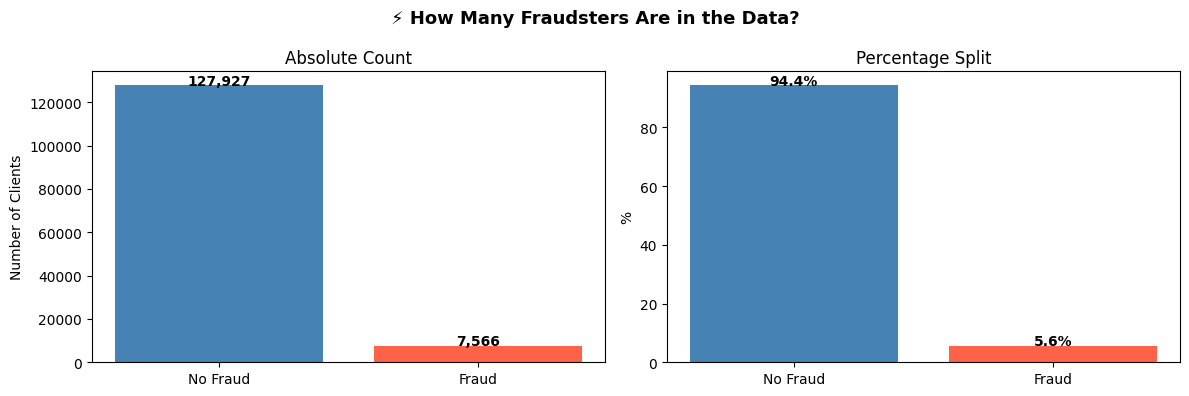

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['steelblue', 'tomato']

# Absolute counts
axes[0].bar(['No Fraud', 'Fraud'], fraud_counts.values, color=colors)
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Number of Clients')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

# Percentages
axes[1].bar(['No Fraud', 'Fraud'], fraud_pct.values, color=colors)
axes[1].set_title('Percentage Split')
axes[1].set_ylabel('%')
for i, v in enumerate(fraud_pct.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('⚡ How Many Fraudsters Are in the Data?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Fix column name typo in original data
df_client.rename(columns={'disrict': 'district'}, inplace=True)

# Strip the 'train_Client_' prefix from IDs and make them integers
df_client['client_id']  = df_client['client_id'].astype(str).str.replace('train_Client_', '').astype(int)
df_invoice['client_id'] = df_invoice['client_id'].astype(str).str.replace('train_Client_', '').astype(int)

# Remove duplicate invoice rows
before = len(df_invoice)
df_invoice.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_invoice):,}')

# Recode rare/noisy values into an "Other" category (99)
df_invoice['counter_statue']      = df_invoice['counter_statue'].astype(str)
df_invoice['reading_remarque']    = df_invoice['reading_remarque'].astype(str)
df_invoice['counter_coefficient'] = df_invoice['counter_coefficient'].astype(str)

df_invoice['counter_statue'].replace(['46','A','618','769','269375','420'], '99', inplace=True)
df_invoice['reading_remarque'].replace(['5','207','413','203'], '99', inplace=True)
df_invoice['counter_coefficient'].replace(['5','11','8','33','50','9','20','10','4'], '99', inplace=True)

print('✅ Cleaning done')

Duplicates removed: 11
✅ Cleaning done


In [ ]:
print('Building features — takes 3-5 mins, please wait...')

df_elec = df_invoice[df_invoice['counter_type'] == 'ELEC'].copy()
df_gaz  = df_invoice[df_invoice['counter_type'] == 'GAZ'].copy()

# ── Consumption stats per client (mean, std, min, max) ──
def consumption_stats(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}'
                   for l, s in agg.columns]
    return agg.reset_index()

total_cons = consumption_stats(df_invoice, 'tot_')
elec_cons  = consumption_stats(df_elec,   'elec_')
gaz_cons   = consumption_stats(df_gaz,    'gaz_')

# ── Mode and unique count of categorical columns per client ──
def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

tarif_elec     = mode_and_count(df_elec,    'tarif_type',         'elec_tarif')
tarif_gaz      = mode_and_count(df_gaz,     'tarif_type',         'gaz_tarif')
counter_status = mode_and_count(df_invoice, 'counter_statue',     'counter_statue')
counter_code   = mode_and_count(df_invoice, 'counter_code',       'counter_code')
remark         = mode_and_count(df_invoice, 'reading_remarque',   'remark')
coeff          = mode_and_count(df_invoice, 'counter_coefficient','coeff')

# ── Invoice count per client ──
invoice_count = df_invoice.groupby('client_id').size().rename('invoice_count').reset_index()

# ── Account duration: first to last invoice ──
def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

elec_dur = account_duration(df_elec, 'elec_')
gaz_dur  = account_duration(df_gaz,  'gaz_')
dur_feat = elec_dur.merge(gaz_dur, on='client_id', how='outer')
dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()

# ── Client account creation date features ──
df_client['acc_creation_year']    = df_client['creation_date'].dt.year
df_client['acc_creation_month']   = df_client['creation_date'].dt.month
df_client['acc_creation_weekday'] = df_client['creation_date'].dt.dayofweek

print('✅ Features built')

Building features — takes 3-5 mins, please wait...
✅ Features built


In [ ]:
print('Merging all features...')

df_merged = df_client.drop(columns=['creation_date'])

for feat_df in [total_cons, elec_cons, gaz_cons,
                tarif_elec, tarif_gaz,
                counter_status, counter_code, remark, coeff,
                invoice_count, dur_feat]:
    df_merged = df_merged.merge(feat_df, on='client_id', how='left')

print(f'Final shape: {df_merged.shape}')
print(f'Fraud rate : {df_merged["target"].mean()*100:.2f}%')

Merging all features...
Final shape: (135493, 72)
Fraud rate : 5.58%


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

X = df_merged.drop(columns=['client_id', 'target'])
y = df_merged['target'].astype(int)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Val size   : {X_val.shape}')
print(f'Fraud in train: {y_train.sum():,}')
print(f'Fraud in val  : {y_val.sum():,}')

Train size : (108394, 70)
Val size   : (27099, 70)
Fraud in train: 6,053
Fraud in val  : 1,513


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print('✅ Preprocessor ready')

✅ Preprocessor ready


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Handle class imbalance by telling XGBoost how lopsided the data is
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'Class weight ratio: {scale_pos_weight:.1f}x')

model = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators       = 500,
        learning_rate      = 0.05,
        max_depth          = 6,
        subsample          = 0.8,
        colsample_bytree   = 0.8,
        scale_pos_weight   = scale_pos_weight,
        eval_metric        = 'auc',
        random_state       = SEED,
        n_jobs             = -1,
        tree_method        = 'hist'
    ))
])

print('Training... (2-4 mins)')
model.fit(X_train, y_train)

val_proba = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_proba)
print(f'\n🏆 Validation ROC-AUC: {auc:.4f}')

Class weight ratio: 16.9x
Training... (2-4 mins)

🏆 Validation ROC-AUC: 0.8067


Best threshold: 0.67

              precision    recall  f1-score   support

    No Fraud       0.96      0.93      0.95     25586
       Fraud       0.25      0.39      0.30      1513

    accuracy                           0.90     27099
   macro avg       0.61      0.66      0.63     27099
weighted avg       0.92      0.90      0.91     27099



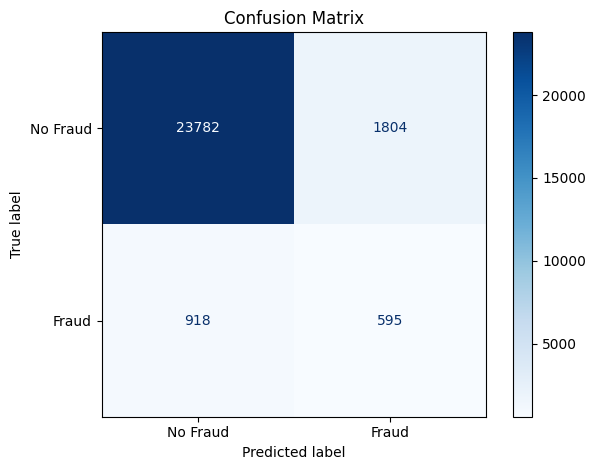

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Find the best threshold for flagging fraud
thresholds = np.arange(0.1, 0.9, 0.01)
from sklearn.metrics import f1_score
f1_scores  = [f1_score(y_val, (val_proba >= t).astype(int), pos_label=1) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Best threshold: {best_thresh:.2f}')

y_pred = (val_proba >= best_thresh).astype(int)

print('\n' + '='*50)
print(classification_report(y_val, y_pred, target_names=['No Fraud','Fraud']))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Fraud','Fraud']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
df_client.rename(columns={'disrict': 'district'}, inplace=True)

df_client['client_id']  = df_client['client_id'].astype(str).str.replace('train_Client_', '').astype(int)
df_invoice['client_id'] = df_invoice['client_id'].astype(str).str.replace('train_Client_', '').astype(int)

df_invoice.drop_duplicates(inplace=True)

df_invoice['counter_statue']      = df_invoice['counter_statue'].astype(str)
df_invoice['reading_remarque']    = df_invoice['reading_remarque'].astype(str)
df_invoice['counter_coefficient'] = df_invoice['counter_coefficient'].astype(str)

df_invoice['counter_statue'].replace(['46','A','618','769','269375','420'], '99', inplace=True)
df_invoice['reading_remarque'].replace(['5','207','413','203'], '99', inplace=True)
df_invoice['counter_coefficient'].replace(['5','11','8','33','50','9','20','10','4'], '99', inplace=True)

print('✅ Done')

✅ Done


In [ ]:
print('Building features, please wait...')

df_elec = df_invoice[df_invoice['counter_type'] == 'ELEC'].copy()
df_gaz  = df_invoice[df_invoice['counter_type'] == 'GAZ'].copy()

def consumption_stats(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}'
                   for l, s in agg.columns]
    return agg.reset_index()

def mode_and_count(df, col, prefix):
    mode_s  = df.groupby('client_id')[col].agg(lambda x: x.mode()[0]).rename(f'{prefix}_mode')
    count_s = df.groupby('client_id')[col].nunique().rename(f'{prefix}_nunique')
    return pd.concat([mode_s, count_s], axis=1).reset_index()

def account_duration(df, prefix):
    dur = df.groupby('client_id')['invoice_date'].agg(['min','max'])
    dur[f'{prefix}dur_years'] = (dur['max'] - dur['min']) / pd.Timedelta(days=365.25)
    return dur[[f'{prefix}dur_years']].reset_index()

total_cons     = consumption_stats(df_invoice, 'tot_')
elec_cons      = consumption_stats(df_elec,    'elec_')
gaz_cons       = consumption_stats(df_gaz,     'gaz_')
tarif_elec     = mode_and_count(df_elec,    'tarif_type',         'elec_tarif')
tarif_gaz      = mode_and_count(df_gaz,     'tarif_type',         'gaz_tarif')
counter_status = mode_and_count(df_invoice, 'counter_statue',     'counter_statue')
counter_code   = mode_and_count(df_invoice, 'counter_code',       'counter_code')
remark         = mode_and_count(df_invoice, 'reading_remarque',   'remark')
coeff          = mode_and_count(df_invoice, 'counter_coefficient','coeff')
invoice_count  = df_invoice.groupby('client_id').size().rename('invoice_count').reset_index()
elec_dur       = account_duration(df_elec, 'elec_')
gaz_dur        = account_duration(df_gaz,  'gaz_')
dur_feat       = elec_dur.merge(gaz_dur, on='client_id', how='outer')
dur_feat['dur_diff_abs'] = (dur_feat['elec_dur_years'] - dur_feat['gaz_dur_years']).abs()

df_client['acc_creation_year']    = df_client['creation_date'].dt.year
df_client['acc_creation_month']   = df_client['creation_date'].dt.month
df_client['acc_creation_weekday'] = df_client['creation_date'].dt.dayofweek

print('✅ Done')

Building features, please wait...
✅ Done


In [ ]:
df_merged = df_client.drop(columns=['creation_date'])

for feat_df in [total_cons, elec_cons, gaz_cons,
                tarif_elec, tarif_gaz,
                counter_status, counter_code, remark, coeff,
                invoice_count, dur_feat]:
    df_merged = df_merged.merge(feat_df, on='client_id', how='left')

print(f'Shape: {df_merged.shape}')

Shape: (135493, 72)


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42
X = df_merged.drop(columns=['client_id', 'target'])
y = df_merged['target'].astype(int)

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape} | Val: {X_val.shape}')

Train: (108394, 70) | Val: (27099, 70)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

neg, pos = np.bincount(y_train)

model = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = neg / pos,
        eval_metric      = 'auc',
        random_state     = SEED,
        n_jobs           = -1,
        tree_method      = 'hist'
    ))
])

print('Training...')
model.fit(X_train, y_train)

val_proba = model.predict_proba(X_val)[:, 1]
print(f'ROC-AUC: {roc_auc_score(y_val, val_proba):.4f}')

Training...
ROC-AUC: 0.8067


In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

thresholds  = np.arange(0.1, 0.9, 0.01)
f1_scores   = [f1_score(y_val, (val_proba >= t).astype(int), pos_label=1) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

y_pred = (val_proba >= best_thresh).astype(int)

print(f'Threshold: {best_thresh:.2f}')
print(classification_report(y_val, y_pred, target_names=['No Fraud','Fraud']))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred))

Threshold: 0.67
              precision    recall  f1-score   support

    No Fraud       0.96      0.93      0.95     25586
       Fraud       0.25      0.39      0.30      1513

    accuracy                           0.90     27099
   macro avg       0.61      0.66      0.63     27099
weighted avg       0.92      0.90      0.91     27099

Confusion Matrix:
[[23782  1804]
 [  918   595]]


In [ ]:
!pip install -q optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold

# Preprocess once so tuning is faster
preprocessor.fit(X_train, y_train)
X_train_prep = preprocessor.transform(X_train)
X_val_prep   = preprocessor.transform(X_val)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'scale_pos_weight':  neg / pos,
        'eval_metric':       'auc',
        'random_state':      SEED,
        'n_jobs':            -1,
        'tree_method':       'hist'
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in cv.split(X_train_prep, y_train):
        clf = XGBClassifier(**params)
        clf.fit(X_train_prep[tr_idx], y_train.iloc[tr_idx], verbose=False)
        proba = clf.predict_proba(X_train_prep[val_idx])[:, 1]
        scores.append(roc_auc_score(y_train.iloc[val_idx], proba))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Best ROC-AUC: {study.best_value:.4f}')
print('Best params:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best ROC-AUC: 0.8160
Best params: {'n_estimators': 311, 'learning_rate': 0.05358396566419826, 'max_depth': 5, 'subsample': 0.8052453460389394, 'colsample_bytree': 0.9683883876229564, 'min_child_weight': 4, 'gamma': 0.9469850109807341, 'reg_alpha': 4.008602953241293, 'reg_lambda': 5.587902276539773}


In [ ]:
best_params = study.best_params
best_params.update({
    'scale_pos_weight': neg / pos,
    'eval_metric':      'auc',
    'random_state':     SEED,
    'n_jobs':           -1,
    'tree_method':      'hist'
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_prep, y_train, verbose=False)

val_proba_tuned = final_model.predict_proba(X_val_prep)[:, 1]
print(f'Tuned ROC-AUC: {roc_auc_score(y_val, val_proba_tuned):.4f}')

Tuned ROC-AUC: 0.8157


In [ ]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    num_leaves       = 63,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    class_weight     = 'balanced',
    random_state     = SEED,
    n_jobs           = -1,
    verbose          = -1
)

lgb_model.fit(X_train_prep, y_train)
lgb_proba = lgb_model.predict_proba(X_val_prep)[:, 1]
print(f'LightGBM ROC-AUC: {roc_auc_score(y_val, lgb_proba):.4f}')

LightGBM ROC-AUC: 0.8060


In [ ]:
# Weighted average of both models' probabilities
ensemble_proba = 0.55 * val_proba_tuned + 0.45 * lgb_proba
print(f'Ensemble ROC-AUC: {roc_auc_score(y_val, ensemble_proba):.4f}')

Ensemble ROC-AUC: 0.8157


In [ ]:
f1_ens   = [f1_score(y_val, (ensemble_proba >= t).astype(int), pos_label=1) for t in thresholds]
best_ens = thresholds[np.argmax(f1_ens)]
y_pred_ens = (ensemble_proba >= best_ens).astype(int)

print(f'Threshold: {best_ens:.2f}')
print(classification_report(y_val, y_pred_ens, target_names=['No Fraud','Fraud']))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_ens))

Threshold: 0.68
              precision    recall  f1-score   support

    No Fraud       0.96      0.94      0.95     25586
       Fraud       0.26      0.39      0.31      1513

    accuracy                           0.90     27099
   macro avg       0.61      0.66      0.63     27099
weighted avg       0.92      0.90      0.91     27099

Confusion Matrix:
[[23930  1656]
 [  929   584]]


In [ ]:
print('Loading test data...')

df_client_test  = pd.read_csv(DATA_DIR + 'client_test.csv',
                               parse_dates=['creation_date'],
                               dayfirst=True)
df_invoice_test = pd.read_csv(DATA_DIR + 'invoice_test.csv',
                               parse_dates=['invoice_date'],
                               dayfirst=True,
                               low_memory=False)

# Clean IDs
df_client_test['client_id']  = df_client_test['client_id'].astype(str).str.replace('test_Client_', '').astype(int)
df_invoice_test['client_id'] = df_invoice_test['client_id'].astype(str).str.replace('test_Client_', '').astype(int)

# Same cleaning as training
df_client_test.rename(columns={'disrict': 'district'}, inplace=True)
df_invoice_test.drop_duplicates(inplace=True)

df_invoice_test['counter_statue']      = df_invoice_test['counter_statue'].astype(str)
df_invoice_test['reading_remarque']    = df_invoice_test['reading_remarque'].astype(str)
df_invoice_test['counter_coefficient'] = df_invoice_test['counter_coefficient'].astype(str)

df_invoice_test['counter_statue'].replace(['46','A','618','769','269375','420'], '99', inplace=True)
df_invoice_test['reading_remarque'].replace(['5','207','413','203'], '99', inplace=True)
df_invoice_test['counter_coefficient'].replace(['5','11','8','33','50','9','20','10','4'], '99', inplace=True)

print('✅ Done')

Loading test data...
✅ Done


In [ ]:
print('Building improved features...')

# ── Region-level fraud rate (powerful signal from EDA) ──
region_fraud_rate = df_client.groupby('region')['target'].mean().rename('region_fraud_rate')
df_client['region_fraud_rate'] = df_client['region'].map(region_fraud_rate)

# ── District-level fraud rate ──
district_fraud_rate = df_client.groupby('district')['target'].mean().rename('district_fraud_rate')
df_client['district_fraud_rate'] = df_client['district'].map(district_fraud_rate)

# ── Invoice date features ──
df_invoice['invoice_year']    = df_invoice['invoice_date'].dt.year
df_invoice['invoice_month']   = df_invoice['invoice_date'].dt.month

df_elec = df_invoice[df_invoice['counter_type'] == 'ELEC'].copy()
df_gaz  = df_invoice[df_invoice['counter_type'] == 'GAZ'].copy()

# ── Consumption variance ratio (fraud clients show irregular consumption) ──
def consumption_variance(df, prefix):
    levels = ['consommation_level_1','consommation_level_2',
              'consommation_level_3','consommation_level_4']
    agg = df.groupby('client_id')[levels].agg(['mean','std','min','max','sum'])
    agg.columns = [f'{prefix}{l.replace("consommation_level_","cl")}_{s}'
                   for l, s in agg.columns]
    # Coefficient of variation (std/mean) — high variation = suspicious
    for lvl in [1,2,3,4]:
        mean_col = f'{prefix}cl{lvl}_mean'
        std_col  = f'{prefix}cl{lvl}_std'
        agg[f'{prefix}cl{lvl}_cv'] = agg[std_col] / (agg[mean_col] + 1e-6)
    return agg.reset_index()

total_cons2     = consumption_variance(df_invoice, 'tot_')
elec_cons2      = consumption_variance(df_elec,    'elec_')
gaz_cons2       = consumption_variance(df_gaz,     'gaz_')

# ── Number of distinct years active ──
def years_active(df, prefix):
    yr = df.groupby('client_id')['invoice_year'].nunique().rename(f'{prefix}years_active')
    return yr.reset_index()

elec_yrs = years_active(df_elec,    'elec_')
gaz_yrs  = years_active(df_gaz,     'gaz_')
tot_yrs  = years_active(df_invoice, 'tot_')

# ── Counter number changes (changing meter = red flag) ──
counter_changes = df_invoice.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index()

# ── Total consumption per client ──
total_kwh = df_invoice.groupby('client_id')[
    ['consommation_level_1','consommation_level_2',
     'consommation_level_3','consommation_level_4']].sum()
total_kwh['total_kwh'] = total_kwh.sum(axis=1)
total_kwh = total_kwh[['total_kwh']].reset_index()

# ── Mode and count features (same as before) ──
tarif_elec2     = mode_and_count(df_elec,    'tarif_type',          'elec_tarif')
tarif_gaz2      = mode_and_count(df_gaz,     'tarif_type',          'gaz_tarif')
counter_status2 = mode_and_count(df_invoice, 'counter_statue',      'counter_statue')
counter_code2   = mode_and_count(df_invoice, 'counter_code',        'counter_code')
remark2         = mode_and_count(df_invoice, 'reading_remarque',    'remark')
coeff2          = mode_and_count(df_invoice, 'counter_coefficient', 'coeff')
invoice_count2  = df_invoice.groupby('client_id').size().rename('invoice_count').reset_index()

elec_dur2  = account_duration(df_elec, 'elec_')
gaz_dur2   = account_duration(df_gaz,  'gaz_')
dur_feat2  = elec_dur2.merge(gaz_dur2, on='client_id', how='outer')
dur_feat2['dur_diff_abs'] = (dur_feat2['elec_dur_years'] - dur_feat2['gaz_dur_years']).abs()

df_client['acc_creation_year']    = df_client['creation_date'].dt.year
df_client['acc_creation_month']   = df_client['creation_date'].dt.month
df_client['acc_creation_weekday'] = df_client['creation_date'].dt.dayofweek

print('✅ Done')

Building improved features...
✅ Done


In [ ]:
df_merged2 = df_client.drop(columns=['creation_date'])

for feat_df in [total_cons2, elec_cons2, gaz_cons2,
                tarif_elec2, tarif_gaz2,
                counter_status2, counter_code2, remark2, coeff2,
                invoice_count2, dur_feat2,
                elec_yrs, gaz_yrs, tot_yrs,
                counter_changes, total_kwh]:
    df_merged2 = df_merged2.merge(feat_df, on='client_id', how='left')

print(f'Shape: {df_merged2.shape}')

Shape: (135493, 103)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X2 = df_merged2.drop(columns=['client_id','target'])
y2 = df_merged2['target'].astype(int)

cat_cols2 = X2.select_dtypes(include=['object','category']).columns.tolist()
num_cols2 = X2.select_dtypes(include=['number']).columns.tolist()

neg2, pos2 = np.bincount(y2)

best_params.update({
    'scale_pos_weight': neg2 / pos2,
    'n_jobs': -1,
    'tree_method': 'hist',
    'random_state': SEED
})

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_proba = np.zeros(len(y2))
cv_scores = []

print('Training 5-fold CV...')
for fold, (tr_idx, val_idx) in enumerate(cv.split(X2, y2), 1):
    X_tr, X_vl = X2.iloc[tr_idx], X2.iloc[val_idx]
    y_tr, y_vl = y2.iloc[tr_idx], y2.iloc[val_idx]

    # Preprocess
    pre2 = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols2),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols2)
    ])

    X_tr_p = pre2.fit_transform(X_tr)
    X_vl_p = pre2.transform(X_vl)

    clf = XGBClassifier(**best_params)
    clf.fit(X_tr_p, y_tr, verbose=False)

    proba = clf.predict_proba(X_vl_p)[:, 1]
    oof_proba[val_idx] = proba
    score = roc_auc_score(y_vl, proba)
    cv_scores.append(score)
    print(f'  Fold {fold}: {score:.4f}')

print(f'\nCV Mean AUC : {np.mean(cv_scores):.4f}')
print(f'OOF AUC     : {roc_auc_score(y2, oof_proba):.4f}')

Training 5-fold CV...
  Fold 1: 0.8696
  Fold 2: 0.8736
  Fold 3: 0.8823
  Fold 4: 0.8666
  Fold 5: 0.8709

CV Mean AUC : 0.8726
OOF AUC     : 0.8725


In [ ]:
# Fit preprocessor on all data
pre_final = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols2),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                             unknown_value=-1))]), cat_cols2)
])

X2_prep = pre_final.fit_transform(X2)

final_model2 = XGBClassifier(**best_params)
final_model2.fit(X2_prep, y2, verbose=False)

print('✅ Final model trained on full dataset')

✅ Final model trained on full dataset


In [ ]:
print('Building test features...')

df_invoice_test['invoice_year']  = df_invoice_test['invoice_date'].dt.year
df_invoice_test['invoice_month'] = df_invoice_test['invoice_date'].dt.month

df_elec_t = df_invoice_test[df_invoice_test['counter_type'] == 'ELEC'].copy()
df_gaz_t  = df_invoice_test[df_invoice_test['counter_type'] == 'GAZ'].copy()

total_cons_t2     = consumption_variance(df_invoice_test, 'tot_')
elec_cons_t2      = consumption_variance(df_elec_t,       'elec_')
gaz_cons_t2       = consumption_variance(df_gaz_t,        'gaz_')
tarif_elec_t2     = mode_and_count(df_elec_t,    'tarif_type',          'elec_tarif')
tarif_gaz_t2      = mode_and_count(df_gaz_t,     'tarif_type',          'gaz_tarif')
counter_status_t2 = mode_and_count(df_invoice_test, 'counter_statue',   'counter_statue')
counter_code_t2   = mode_and_count(df_invoice_test, 'counter_code',     'counter_code')
remark_t2         = mode_and_count(df_invoice_test, 'reading_remarque', 'remark')
coeff_t2          = mode_and_count(df_invoice_test, 'counter_coefficient','coeff')
invoice_count_t2  = df_invoice_test.groupby('client_id').size().rename('invoice_count').reset_index()
elec_dur_t2       = account_duration(df_elec_t, 'elec_')
gaz_dur_t2        = account_duration(df_gaz_t,  'gaz_')
dur_feat_t2       = elec_dur_t2.merge(gaz_dur_t2, on='client_id', how='outer')
dur_feat_t2['dur_diff_abs'] = (dur_feat_t2['elec_dur_years'] - dur_feat_t2['gaz_dur_years']).abs()
elec_yrs_t  = years_active(df_elec_t,       'elec_')
gaz_yrs_t   = years_active(df_gaz_t,        'gaz_')
tot_yrs_t   = years_active(df_invoice_test, 'tot_')
counter_changes_t = df_invoice_test.groupby('client_id')['counter_number'].nunique().rename('counter_changes').reset_index()
total_kwh_t = df_invoice_test.groupby('client_id')[
    ['consommation_level_1','consommation_level_2',
     'consommation_level_3','consommation_level_4']].sum()
total_kwh_t['total_kwh'] = total_kwh_t.sum(axis=1)
total_kwh_t = total_kwh_t[['total_kwh']].reset_index()

# Region and district fraud rates from training data
df_client_test['region_fraud_rate']   = df_client_test['region'].map(region_fraud_rate)
df_client_test['district_fraud_rate'] = df_client_test['district'].map(district_fraud_rate)

df_client_test['acc_creation_year']    = df_client_test['creation_date'].dt.year
df_client_test['acc_creation_month']   = df_client_test['creation_date'].dt.month
df_client_test['acc_creation_weekday'] = df_client_test['creation_date'].dt.dayofweek

df_test_merged2 = df_client_test.drop(columns=['creation_date'])

for feat_df in [total_cons_t2, elec_cons_t2, gaz_cons_t2,
                tarif_elec_t2, tarif_gaz_t2,
                counter_status_t2, counter_code_t2, remark_t2, coeff_t2,
                invoice_count_t2, dur_feat_t2,
                elec_yrs_t, gaz_yrs_t, tot_yrs_t,
                counter_changes_t, total_kwh_t]:
    df_test_merged2 = df_test_merged2.merge(feat_df, on='client_id', how='left')

print(f'Test shape: {df_test_merged2.shape}')

Building test features...
Test shape: (58069, 102)


In [ ]:
print('Building advanced features...')

# ── Consecutive zero consumption (meter tampering signal) ──
def zero_consumption_ratio(df, prefix):
    df = df.copy()
    df['total_consum'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                          df['consommation_level_3'] + df['consommation_level_4'])
    zero = df.groupby('client_id')['total_consum'].apply(lambda x: (x == 0).sum()).rename(f'{prefix}zero_count')
    ratio = df.groupby('client_id')['total_consum'].apply(lambda x: (x == 0).mean()).rename(f'{prefix}zero_ratio')
    return pd.concat([zero, ratio], axis=1).reset_index()

zero_elec = zero_consumption_ratio(df_elec, 'elec_')
zero_gaz  = zero_consumption_ratio(df_gaz,  'gaz_')
zero_tot  = zero_consumption_ratio(df_invoice, 'tot_')

# ── Max single invoice consumption (spike detection) ──
def max_single_invoice(df, prefix):
    df = df.copy()
    df['total_consum'] = (df['consommation_level_1'] + df['consommation_level_2'] +
                          df['consommation_level_3'] + df['consommation_level_4'])
    mx  = df.groupby('client_id')['total_consum'].max().rename(f'{prefix}max_invoice')
    med = df.groupby('client_id')['total_consum'].median().rename(f'{prefix}median_invoice')
    skw = df.groupby('client_id')['total_consum'].skew().rename(f'{prefix}skew_invoice')
    return pd.concat([mx, med, skw], axis=1).reset_index()

max_elec = max_single_invoice(df_elec,    'elec_')
max_gaz  = max_single_invoice(df_gaz,     'gaz_')
max_tot  = max_single_invoice(df_invoice, 'tot_')

# ── Invoice gap: average days between invoices ──
def invoice_gap(df, prefix):
    df = df.sort_values(['client_id','invoice_date'])
    gaps = df.groupby('client_id')['invoice_date'].apply(
        lambda x: x.diff().dt.days.mean()
    ).rename(f'{prefix}avg_gap_days')
    return gaps.reset_index()

gap_elec = invoice_gap(df_elec,    'elec_')
gap_gaz  = invoice_gap(df_gaz,     'gaz_')

# ── Counter statue changes (status flipping = suspicious) ──
statue_changes = df_invoice.groupby('client_id')['counter_statue'].nunique().rename('statue_changes').reset_index()

# ── Client category fraud rate ──
catg_fraud_rate = df_client.groupby('client_catg')['target'].mean().rename('catg_fraud_rate')
df_client['catg_fraud_rate'] = df_client['client_catg'].map(catg_fraud_rate)

print('✅ Done')

Building advanced features...
✅ Done


In [ ]:
df_merged3 = df_client.drop(columns=['creation_date'])

for feat_df in [total_cons2, elec_cons2, gaz_cons2,
                tarif_elec2, tarif_gaz2,
                counter_status2, counter_code2, remark2, coeff2,
                invoice_count2, dur_feat2,
                elec_yrs, gaz_yrs, tot_yrs,
                counter_changes, total_kwh,
                zero_elec, zero_gaz, zero_tot,
                max_elec, max_gaz, max_tot,
                gap_elec, gap_gaz,
                statue_changes]:
    df_merged3 = df_merged3.merge(feat_df, on='client_id', how='left')

print(f'Shape: {df_merged3.shape}')

Shape: (135493, 122)


In [ ]:
X3 = df_merged3.drop(columns=['client_id','target'])
y3 = df_merged3['target'].astype(int)

cat_cols3 = X3.select_dtypes(include=['object','category']).columns.tolist()
num_cols3 = X3.select_dtypes(include=['number']).columns.tolist()

neg3, pos3 = np.bincount(y3)

print(f'X3 shape: {X3.shape}')

X3 shape: (135493, 120)


In [ ]:
print('Building advanced test features...')

df_elec_t = df_invoice_test[df_invoice_test['counter_type'] == 'ELEC'].copy()
df_gaz_t  = df_invoice_test[df_invoice_test['counter_type'] == 'GAZ'].copy()

zero_elec_t = zero_consumption_ratio(df_elec_t,       'elec_')
zero_gaz_t  = zero_consumption_ratio(df_gaz_t,        'gaz_')
zero_tot_t  = zero_consumption_ratio(df_invoice_test, 'tot_')
max_elec_t  = max_single_invoice(df_elec_t,           'elec_')
max_gaz_t   = max_single_invoice(df_gaz_t,            'gaz_')
max_tot_t   = max_single_invoice(df_invoice_test,     'tot_')
gap_elec_t  = invoice_gap(df_elec_t,    'elec_')
gap_gaz_t   = invoice_gap(df_gaz_t,     'gaz_')
statue_changes_t = df_invoice_test.groupby('client_id')['counter_statue'].nunique().rename('statue_changes').reset_index()

df_client_test['catg_fraud_rate'] = df_client_test['client_catg'].map(catg_fraud_rate)

df_test_merged3 = df_client_test.drop(columns=['creation_date'], errors='ignore')

for feat_df in [total_cons_t2, elec_cons_t2, gaz_cons_t2,
                tarif_elec_t2, tarif_gaz_t2,
                counter_status_t2, counter_code_t2, remark_t2, coeff_t2,
                invoice_count_t2, dur_feat_t2,
                elec_yrs_t, gaz_yrs_t, tot_yrs_t,
                counter_changes_t, total_kwh_t,
                zero_elec_t, zero_gaz_t, zero_tot_t,
                max_elec_t, max_gaz_t, max_tot_t,
                gap_elec_t, gap_gaz_t,
                statue_changes_t]:
    df_test_merged3 = df_test_merged3.merge(feat_df, on='client_id', how='left')

test_ids3 = df_test_merged3['client_id'].copy()
X_test3   = df_test_merged3.drop(columns=['client_id'], errors='ignore')
X_test3   = X_test3.reindex(columns=X3.columns, fill_value=np.nan)

print(f'Test shape: {df_test_merged3.shape}')

Building advanced test features...
Test shape: (58069, 121)


In [ ]:
from lightgbm import LGBMClassifier

X3 = df_merged3.drop(columns=['client_id','target'])
y3 = df_merged3['target'].astype(int)

cat_cols3 = X3.select_dtypes(include=['object','category']).columns.tolist()
num_cols3 = X3.select_dtypes(include=['number']).columns.tolist()

neg3, pos3 = np.bincount(y3)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(len(y3))
oof_lgb = np.zeros(len(y3))

test_xgb_preds = []
test_lgb_preds = []

print('Training 5-fold CV — XGBoost + LightGBM...')

for fold, (tr_idx, val_idx) in enumerate(cv.split(X3, y3), 1):
    X_tr, X_vl = X3.iloc[tr_idx], X3.iloc[val_idx]
    y_tr, y_vl = y3.iloc[tr_idx], y3.iloc[val_idx]

    pre3 = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num_cols3),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                                 unknown_value=-1))]), cat_cols3)
    ])

    X_tr_p = pre3.fit_transform(X_tr)
    X_vl_p = pre3.transform(X_vl)

    # XGBoost
    xgb_clf = XGBClassifier(**best_params)
    xgb_clf.fit(X_tr_p, y_tr, verbose=False)
    oof_xgb[val_idx] = xgb_clf.predict_proba(X_vl_p)[:, 1]

    # LightGBM
    lgb_clf = LGBMClassifier(
        n_estimators     = best_params.get('n_estimators', 500),
        learning_rate    = best_params.get('learning_rate', 0.05),
        num_leaves       = 63,
        subsample        = best_params.get('subsample', 0.8),
        colsample_bytree = best_params.get('colsample_bytree', 0.8),
        class_weight     = 'balanced',
        random_state     = SEED,
        n_jobs           = -1,
        verbose          = -1
    )
    lgb_clf.fit(X_tr_p, y_tr)
    oof_lgb[val_idx] = lgb_clf.predict_proba(X_vl_p)[:, 1]

    # Test predictions per fold (averaged later)
    X_test3_p = pre3.transform(X_test3)
    test_xgb_preds.append(xgb_clf.predict_proba(X_test3_p)[:, 1])
    test_lgb_preds.append(lgb_clf.predict_proba(X_test3_p)[:, 1])

    xgb_score = roc_auc_score(y_vl, oof_xgb[val_idx])
    lgb_score = roc_auc_score(y_vl, oof_lgb[val_idx])
    print(f'  Fold {fold} — XGB: {xgb_score:.4f} | LGB: {lgb_score:.4f}')

print(f'\nOOF XGBoost : {roc_auc_score(y3, oof_xgb):.4f}')
print(f'OOF LightGBM: {roc_auc_score(y3, oof_lgb):.4f}')

Training 5-fold CV — XGBoost + LightGBM...
  Fold 1 — XGB: 0.8700 | LGB: 0.8639
  Fold 2 — XGB: 0.8707 | LGB: 0.8650
  Fold 3 — XGB: 0.8826 | LGB: 0.8778
  Fold 4 — XGB: 0.8667 | LGB: 0.8608
  Fold 5 — XGB: 0.8695 | LGB: 0.8646

OOF XGBoost : 0.8718
OOF LightGBM: 0.8664


In [ ]:
# Average test predictions across all folds
test_xgb_mean = np.mean(test_xgb_preds, axis=0)
test_lgb_mean = np.mean(test_lgb_preds, axis=0)

# Blend — weight XGBoost slightly higher since it scored better before
ensemble_test = 0.6 * test_xgb_mean + 0.4 * test_lgb_mean

# Also check blend score on OOF
oof_blend = 0.6 * oof_xgb + 0.4 * oof_lgb
print(f'OOF Blend AUC: {roc_auc_score(y3, oof_blend):.4f}')

submission4 = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids3.astype(str),
    'target':    ensemble_test
})

sub_path4 = DATA_DIR + 'submission_v4.csv'
submission4.to_csv(sub_path4, index=False)
print(f'✅ Saved: {sub_path4}')

OOF Blend AUC: 0.8723
✅ Saved: /content/drive/MyDrive/STEG_Fraud/submission_v4.csv


In [ ]:
# ROC-AUC is computed from probabilities, not 0/1 labels
# Submitting raw probabilities gives Zindi more information to score with

submission3 = pd.DataFrame({
    'client_id': 'test_Client_' + test_ids2.astype(str),
    'target':    test_proba2        # <-- probabilities, not 0/1
})

sub_path3 = DATA_DIR + 'submission_v3.csv'
submission3.to_csv(sub_path3, index=False)
print(f'✅ Saved: {sub_path3}')
print(submission4.head())

NameError: name 'test_ids2' is not defined